环境准备

In [20]:
import cfe
import scanpy as sc

cfe.settings.backend = "python_function"
cfe.logger.setLevel("DEBUG")
import pandas as pd
import numpy as np
from cfe.data import FateAnnData
import matplotlib.pyplot as plt
import seaborn as sns
#这里尝试仅调用一个接口计算聚合指标
from cfe.metric import calculate_metrics

数据准备和预处理

In [21]:
# 读取scvelo的pancreas数据
adata = sc.read_h5ad("/home/huang/PyCode/scRNA/data/Pancreas/endocrinogenesis_day15.h5ad")
fadata = cfe.data.FateAnnData.from_anndata(adata)
fadata.layers["expression"] = fadata.layers["spliced"]
fadata.layers["count"] = fadata.layers["spliced"]

basis = "umap"
cluster_key = "clusters"

fadata.obs.index = [f"cell_{i:03d}" for i in range(fadata.shape[0])]
fadata

[2025年10月09日 22时00分04秒] DEBUG    Create a FateAnnData object from an existing AnnData object.                


AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'cfe'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'count'

In [22]:
fadata.layers["expression"].toarray()[:20, :20] #查看表达矩阵

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 2., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1.,
        0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
        0., 0., 1., 2.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
        0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
        0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1.,
        0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 2.,
        0., 0., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0.

In [23]:
#表达矩阵简单预处理
# Normalizing to median total counts
sc.pp.normalize_total(fadata)
# Logarithmize the data
sc.pp.log1p(fadata)

# Feature selection
sc.pp.highly_variable_genes(fadata, n_top_genes=2000)
fadata = fadata[:, fadata.var.highly_variable]
fadata

[2025年10月09日 22时00分05秒] DEBUG    Create a FateAnnData object from an existing AnnData object.                


AnnData object with n_obs × n_vars = 3696 × 2000
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score'
    var: 'highly_variable_genes', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'cfe', 'log1p', 'hvg'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'count'

In [24]:
fadata.X.toarray()[:20, :20]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.8110648 , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.8110648 , 2.8480403 , 1.252936  , 0.        ],
       [0.        , 0.        , 1.2886586 , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 1.0123078 ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.9249996 , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 2.3156202 , 0.9249996 , 0.        ],
       [0.        , 0.5543057 , 0.90884864, 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.5543057 ,
        0.        , 0.        , 0.        , 0

In [25]:
# 手动添加参考里程碑
milestone_network = pd.DataFrame(
    data=[
        ["Ductal", "Ngn3 low EP"],
        ["Ngn3 low EP", "Ngn3 high EP"],
        ["Ngn3 high EP", "Pre-endocrine"],
        ["Pre-endocrine", "Alpha"],
        ["Pre-endocrine", "Beta"],
        ["Pre-endocrine", "Delta"],
        ["Pre-endocrine", "Epsilon"],
    ],
    columns=["from", "to"],
)

fadata.add_trajectory_mannually(milestone_network)

                        DEBUG    FateAnnData add_trajectory                                                        


[2025年10月09日 22时00分57秒] DEBUG    plot_trajectory                                                             
[2025年10月09日 22时01分40秒] DEBUG    add waypoints                                                               
                        DEBUG    FateAnnData add_waypoints                                                         
[2025年10月09日 22时01分47秒] DEBUG    add waypoints shape is (212, 3696), finished!                               


AnnData object with n_obs × n_vars = 3696 × 2000
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'milestone_color', 'milestone'
    var: 'highly_variable_genes', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'cfe', 'log1p', 'hvg', 'milestone_colors', 'milestone_color_colors', 'milestone_color_dict'
    obsm: 'X_pca', 'X_umap', 'milestone_network_emb'
    layers: 'spliced', 'unspliced', 'expression', 'count'

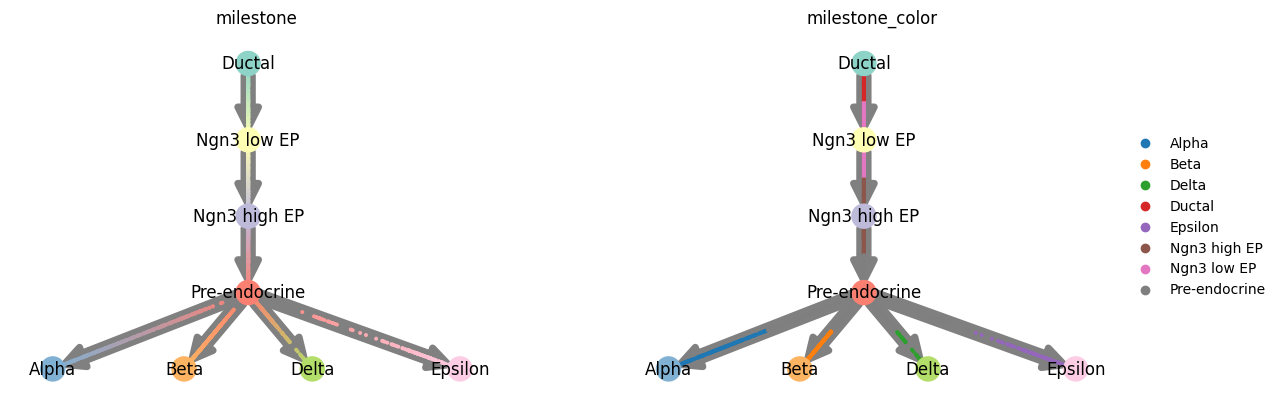

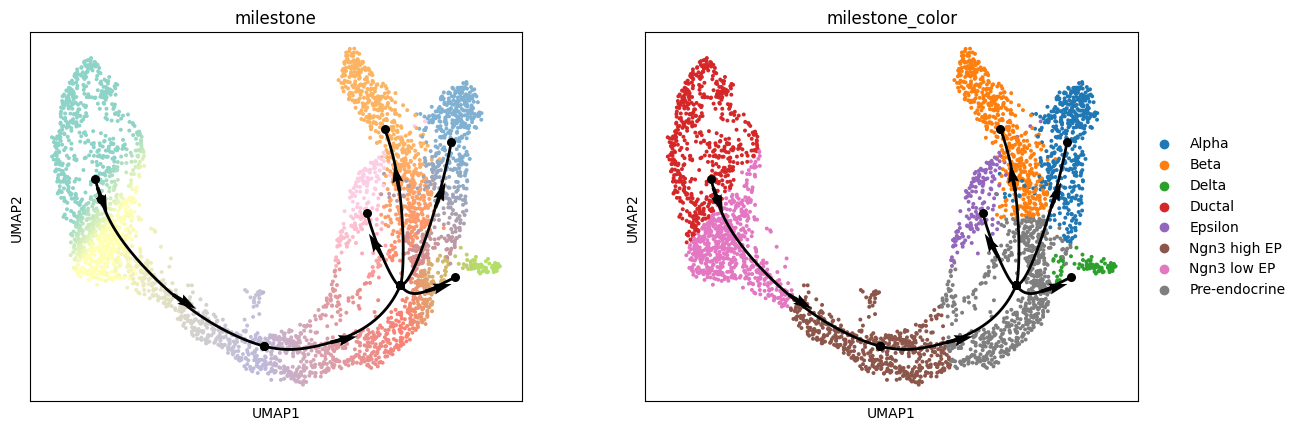

In [26]:
cluster_key = "milestone_color"
fadata.group_onto_nearest_milestones(cluster_key=cluster_key)  # new cluster color

cluster_key_list = ["milestone", cluster_key]
cfe.plot.plot_graph(fadata, color=cluster_key_list)
cfe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list)
fadata

In [27]:
#先验
prior_information = {"start_id": fadata.obs.index[0], "groups_id": fadata.obs[cluster_key].tolist()}
parameters = {"filter_features": False, "connectivity_cutoff": 0.3}
fadata.add_prior_information(**prior_information)  # add prior information to fadata

调用方法获取各方法模型对应的轨迹信息

[2025年10月09日 22时03分02秒] DEBUG    FunctionBackend __init__                                                    
                        INFO     Loaded function: <function cf_comp1 at 0x75b3003080d0> from                       
                                 /home/mhn/Code/CellFateExplorer/cfe/method/function/cf_comp1.py                   
                        INFO     method_backend: <cfe.method.fate_function_backend.FunctionBackend object at       
                                 0x75b3081b1ea0>                                                                   


                        DEBUG    Add trajectory by wrapper type: linear                                            
                        DEBUG    Wrapper type: linear                                                              
                        DEBUG    FateAnnData add_trajectory                                                        
[2025年10月09日 22时03分03秒] DEBUG    plot_trajectory                                                             
[2025年10月09日 22时03分46秒] DEBUG    add waypoints                                                               
                        DEBUG    FateAnnData add_waypoints                                                         
[2025年10月09日 22时04分00秒] DEBUG    add waypoints shape is (201, 3696), finished!                               
[2025年10月09日 22时04分03秒] DEBUG    FunctionBackend __init__                                                    
                        INFO     Loaded function: <function cf_state_comp at 0x75b351568dc0> fro

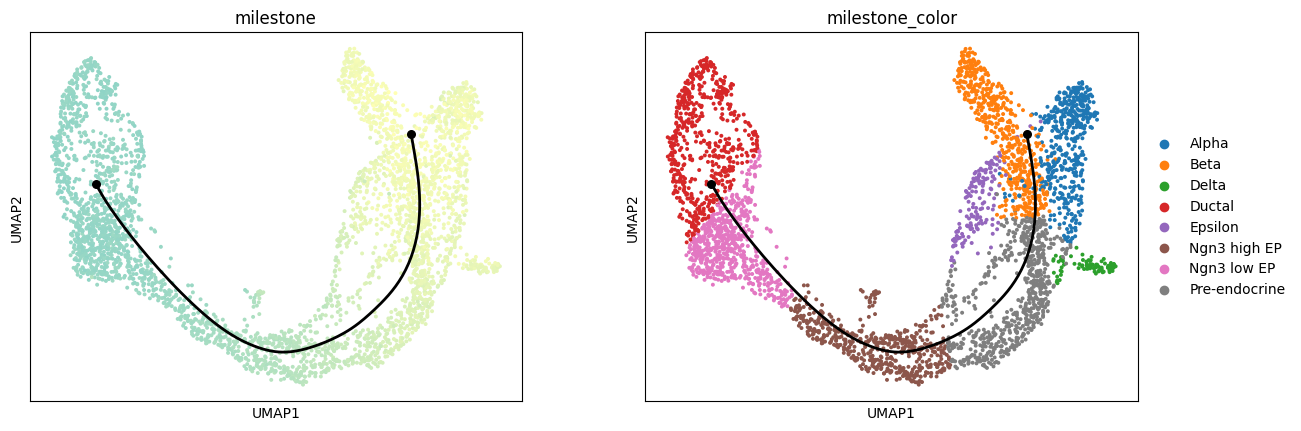

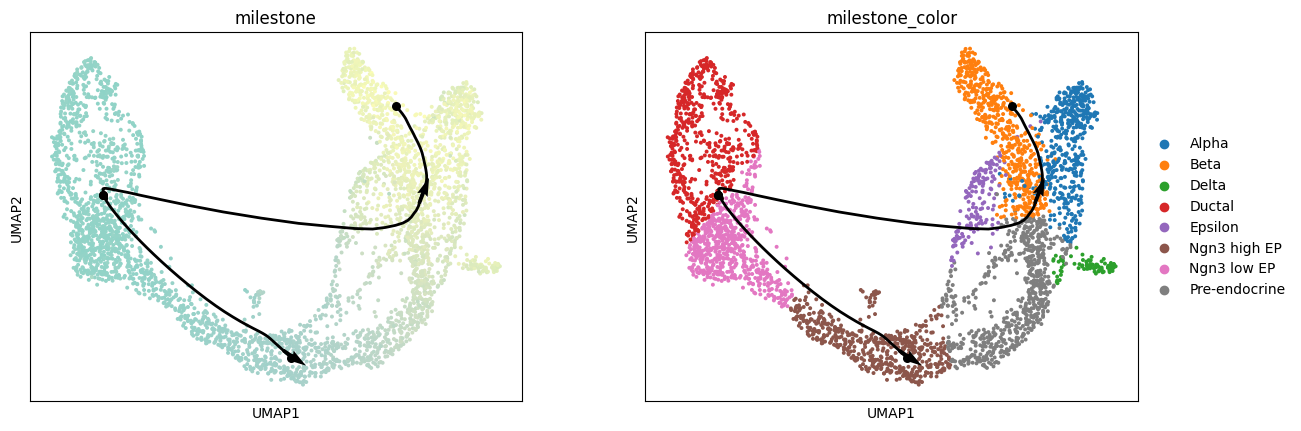

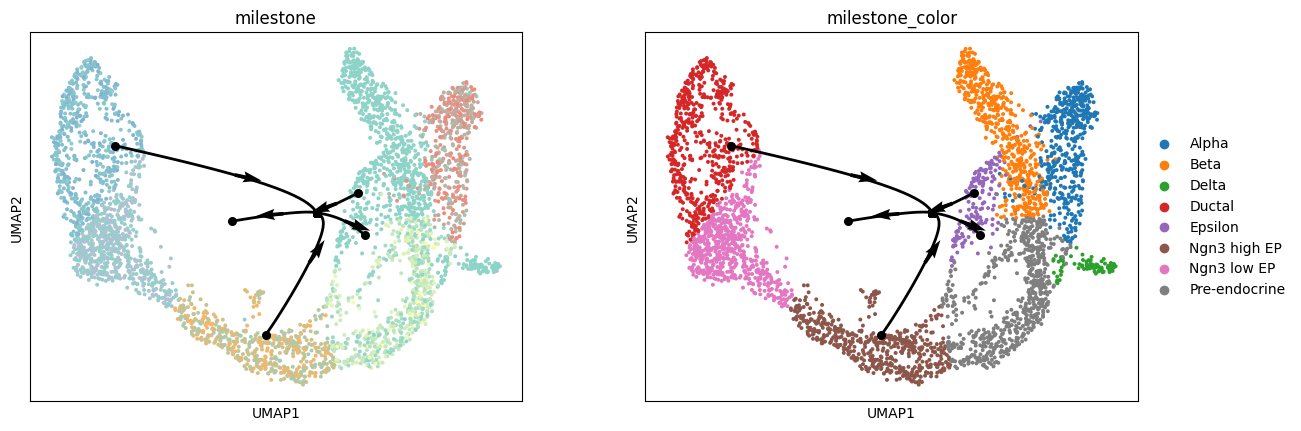

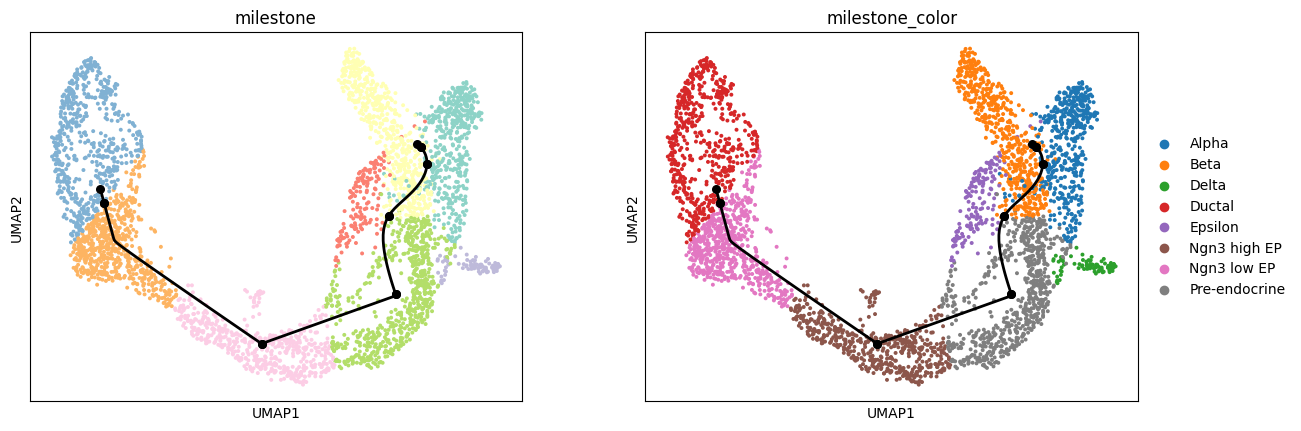

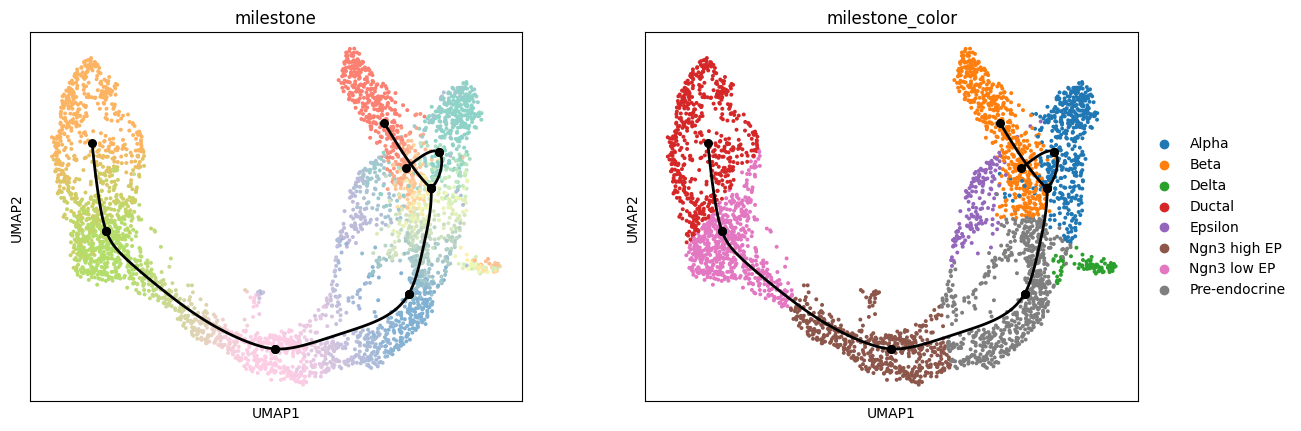

In [28]:
method_name_list = ["comp1", "state_comp", "paga", "cluster_mst", "projection_mst"]
for method_name in method_name_list:
    method = cfe.method.FateMethod(method_name=method_name)
    method.infer_trajectory(fadata)
    cfe.plot.plot_trajectory(fadata, basis="umap", color=cluster_key_list)#绘图

In [29]:
parsed_model_name_list = fadata.get_all_model_name()  # 解析后的模型名称
model_name_list = fadata.get_all_model_name(parse=False)
parsed_model_name_list, model_name_list

[2025年10月09日 22时11分08秒] WARNING  'ref' is not a valid random_time_string, don't need parse                   


(['ref',
  'comp1-python_function',
  'state_comp-python_function',
  'paga-python_function',
  'cluster_mst-python_function',
  'projection_mst-python_function'],
 ['ref',
  '20251009_220302__comp1-python_function__F3Qp12pEIK',
  '20251009_220403__state_comp-python_function__p9sImd5a9u',
  '20251009_220510__paga-python_function__56gXSPTMJZ',
  '20251009_220617__cluster_mst-python_function__ELPOT3bUy4',
  '20251009_220712__projection_mst-python_function__A5Qn9W8gk3'])

指标计算